<center>

# **Predicción del precio y clasificación de autos usados.**

</center>

## **Contexto**
Este es un dataset actualizado cada pocos meses que contiene casi toda la información relevante que Craigslist proporciona sobre las ventas de autos, incluyendo columnas como precio, condición, fabricante, latitud/longitud, y otras 18 categorías.

### Objetivo
Diseñar modelos supervisados de regresión y clasificación binaria utilizando técnicas de regresión lineal regularizada (Ridge, Lasso) y regresión logística, integradas en un flujo completo con Pipeline y búsqueda de hiperparámetros mediante GridSearchCV, con el propósito de:

* Estimar el precio de un auto usado a partir de sus características (tarea de regresión).

* Clasificar si un vehículo está en alta demanda o baja demanda (tarea de clasificación binaria).

## Descripción de las variables.

*   **`id`**: Un identificador único para cada anuncio en el dataset.
*   **`url`**: El enlace (URL) al anuncio original en Craigslist.
*   **`region`**: La región general de Craigslist donde se publicó el anuncio (e.g., `sf bay area`, `maine`).
*   **`region_url`**: El URL de la página principal de la región de Craigslist.
*   **`price`**: El precio de venta del vehículo, en dólares estadounidenses ($). Es la variable objetivo principal.
*   **`year`**: El año de fabricación del vehículo.
*   **`manufacturer`**: El fabricante o marca del vehículo (e.g., `ford`, `toyota`, `bmw`).
*   **`model`**: El modelo específico del vehículo (e.g., `mustang`, `camry`, `x5`).
*   **`condition`**: La condición en la que se encuentra el vehículo (e.g., `excellent`, `good`, `fair`, `salvage`).
*   **`cylinders`**: El tipo de configuración de cilindros del motor (e.g., `4 cylinders`, `6 cylinders`, `v8`).
*   **`fuel`**: El tipo de combustible que utiliza el vehículo (e.g., `gas`, `diesel`, `electric`, `hybrid`).
*   **`odometer`**: El kilometraje que ha recorrido el vehículo (en millas).
*   **`title_status`**: El estado legal del título del vehículo (e.g., `clean`, `salvage`, `rebuilt`, `lien`).
*   **`transmission`**: El tipo de transmisión (e.g., `automatic`, `manual`, `other`).
*   **`VIN`**(Vehicle Identification Number): El número de identificación único del vehículo.
*   **`drive`**: La tracción del vehículo (e.g., `4wd` (tracción en las 4 ruedas), `fwd` (tracción delantera), `rwd` (tracción trasera)).
*   **`size`**: La categoría de tamaño del vehículo (e.g., `compact`, `mid-size`, `full-size`, `sub-compact`).
*   **`type`**: El tipo de carrocería del vehículo (e.g., `sedan`, `SUV`, `truck`, `coupe`, `wagon`).
*   **`paint_color`**: El color del vehículo.
*   **`image_url`**: El enlace (URL) a la imagen principal del anuncio.
*   **`description`**: El texto de descripción proporcionado por el vendedor en el anuncio.
*   **`county`**: El condado (dentro de la región) (Está vacía), el mismo dataset dice que es un error.
*   **`state`**: El estado de EE. UU. (abreviado, e.g., `ca`, `ny`) donde se publicó el anuncio.
*   **`lat`**: La latitud de la ubicación del vehículo.
*   **`long`**: La longitud de la ubicación del vehículo.
*   **`posting_date`**: La fecha en la que el anuncio fue publicado en Craigslist.


## **EDA**

### **Imports y cargar los datos.**

In [ ]:
import numpy as np
import pandas as pd
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import pandas as pd
import warnings
# Suprimir warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn._oldcore")
warnings.filterwarnings("ignore", 
                        message="invalid value encountered in greater",
                        category=RuntimeWarning,
                        module="pandas.io.formats.format")
warnings.filterwarnings("ignore", 
                        message="invalid value encountered in less",
                        category=RuntimeWarning,
                        module="pandas.io.formats.format")

In [2]:
df = pd.read_csv('/kaggle/input/craigslist-carstrucks-data/vehicles.csv')

In [3]:
print(f"El dataset tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El dataset tiene 426880 filas y 26 columnas.


In [4]:
df.columns

Index(['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer',
       'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status',
       'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color',
       'image_url', 'description', 'county', 'state', 'lat', 'long',
       'posting_date'],
      dtype='object')

In [5]:
df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,...,NaN,sedan,NaN,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,NaN,...,NaN,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,NaN,...,NaN,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,...,NaN,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  object 
 2   region        426880 non-null  object 
 3   region_url    426880 non-null  object 
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  object 
 7   model         421603 non-null  object 
 8   condition     252776 non-null  object 
 9   cylinders     249202 non-null  object 
 10  fuel          423867 non-null  object 
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  object 
 13  transmission  424324 non-null  object 
 14  VIN           265838 non-null  object 
 15  drive         296313 non-null  object 
 16  size          120519 non-null  object 
 17  type          334022 non-null  object 
 18  pain

In [7]:
# Eliminar columnas irrelevantes o redundantes
cols_to_drop = [
    'id', 'url', 'region_url', 'VIN', 'image_url', 
    'description', 'county', 'lat', 'long', 'posting_date'
]
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Columnas eliminadas: {cols_to_drop}")

Columnas eliminadas: ['id', 'url', 'region_url', 'VIN', 'image_url', 'description', 'county', 'lat', 'long', 'posting_date']


## **Análsis de NA** 

In [8]:
# Manejo de valores faltantes
# Calculamos el porcentaje de valores nulos por columna
missing_percentage = df_cleaned.isnull().sum() / len(df_cleaned) * 100
print("\nPorcentaje de valores faltantes por columna:")
print(missing_percentage.sort_values(ascending=False))


Porcentaje de valores faltantes por columna:
size            71.767476
cylinders       41.622470
condition       40.785232
drive           30.586347
paint_color     30.501078
type            21.752717
manufacturer     4.133714
title_status     1.930753
model            1.236179
odometer         1.030735
fuel             0.705819
transmission     0.598763
year             0.282281
region           0.000000
price            0.000000
state            0.000000
dtype: float64


In [9]:
df_cleaned.isna().sum()

region               0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
drive           130567
size            306361
type             92858
paint_color     130203
state                0
dtype: int64

In [10]:
# Eliminamos la columna size con más de un 70% de valores faltantes
df_cleaned.drop(columns= ['size'], inplace=True)

In [11]:
print(f"\nDimensiones del dataset: {df_cleaned.shape}")


Dimensiones del dataset: (426880, 15)


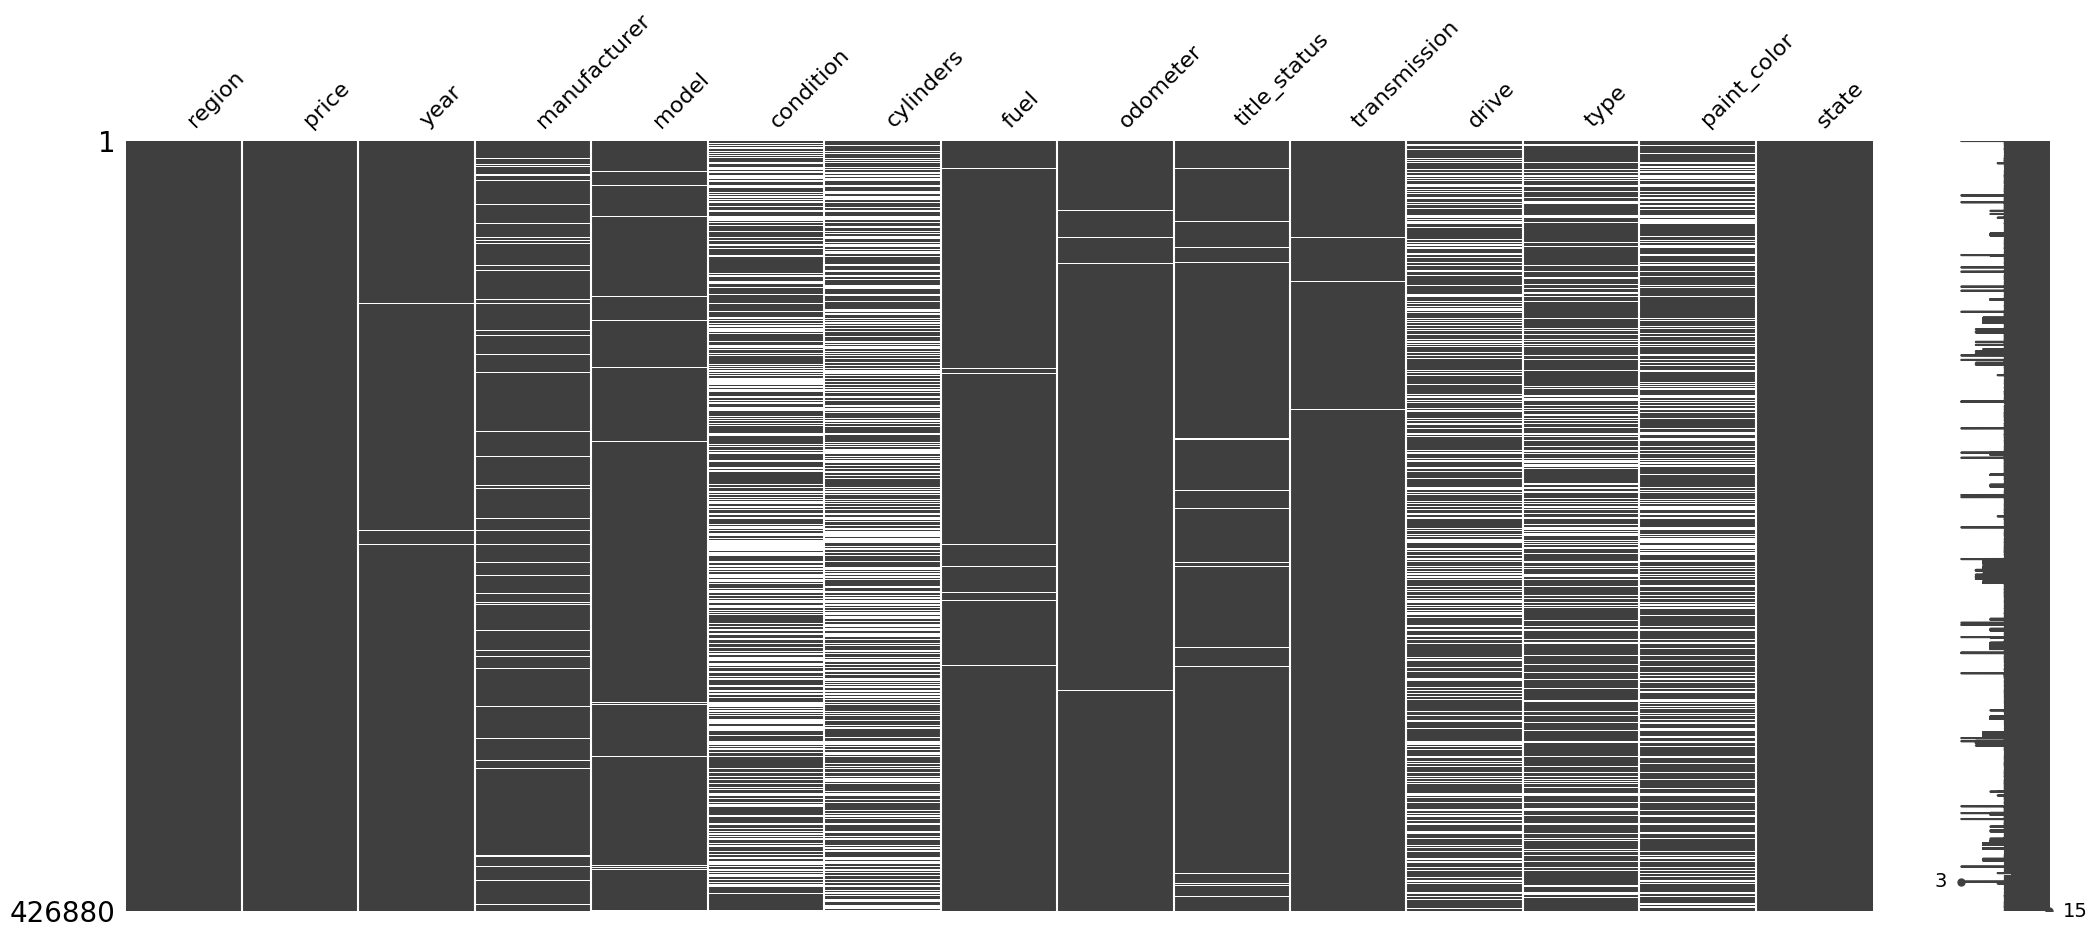

In [12]:
# Visualizar mapa de datos faltantes
msno.matrix(df_cleaned)
plt.show()

Observamos que en nuestras variables significativas aquellas con mayor cantidad de valores perdidos son Cylinders y Conditions. Mientras que otras como State y Region se encuentran completas

Se procede a eliminar las filas que contienen valores nulos específicamente en las columnas `title_status`, `model`, `odometer`, `fuel`, `year`, `type`,`manufacturer`,`transmission`. Esta decisión se basa en que la proporción de datos faltantes en estas columnas es inferior al 5% del total, por lo que su eliminación no afectará significativamente la integridad del conjunto de datos.

In [13]:
# Definimos las columnas en las que buscaremos valores nulos
columns_to_clean = ['title_status', 'model', 'odometer', 'fuel', 'year', 'type', 'manufacturer', 'transmission' ]

# Mostramos las dimensiones del DataFrame antes de la eliminación
print(f"Dimensiones originales: {df_cleaned.shape}")

# Eliminamos las filas que tienen NA *solo en el subconjunto de columnas especificado*
df_cleaned = df_cleaned.dropna(subset=columns_to_clean)

# Mostramos las nuevas dimensiones para verificar el cambio
print(f"Dimensiones después de eliminar NAs en columnas específicas: {df_cleaned.shape}")

Dimensiones originales: (426880, 15)
Dimensiones después de eliminar NAs en columnas específicas: (306976, 15)


Para 'paint_color' debemos observar si tiene un impacto en el precio de los carros, de no ser importante (lo que es probable), eliminaremos la columna.

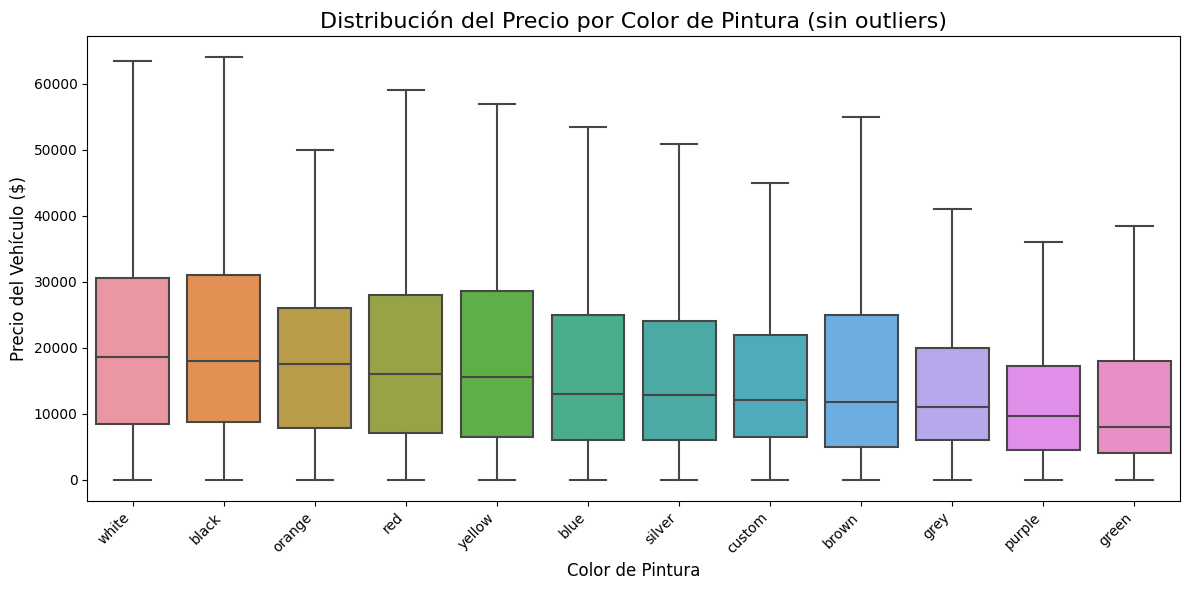

In [14]:
order = df_cleaned.groupby('paint_color')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 6))
sns.boxplot(
    x='paint_color', 
    y='price', 
    data=df_cleaned, 
    order=order,
    showfliers=False  # Esto oculta los outliers completamente
)

plt.title('Distribución del Precio por Color de Pintura (sin outliers)', fontsize=16)
plt.xlabel('Color de Pintura', fontsize=12)
plt.ylabel('Precio del Vehículo ($)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

No se observa una diferencia importante asi que se eliminará la columna para reducir el ruido.

In [15]:
df_cleaned = df_cleaned.drop(columns=['paint_color'])

## **Imputación**

### **Outliers**

Es hora de decidir sobre los outliers de `price` y de `odometer`.

In [16]:
# Verificación completa datos
def check_data_issues(df):
    print("=== VERIFICACIÓN DE DATOS ===")
    print(f"Valores NaN: {df.isna().sum().sum()}")
    
    # Verificar columnas numéricas específicas
    numeric_cols = ['price', 'odometer']
    for col in numeric_cols:
        if col in df.columns:
            print(f"\n--- {col} ---")
            print(f"NaN: {df[col].isna().sum()}")
            print(f"Mínimo: {df[col].min()}")
            print(f"Máximo: {df[col].max()}")

# Ejecutar verificación
check_data_issues(df_cleaned)

=== VERIFICACIÓN DE DATOS ===
Valores NaN: 269749

--- price ---
NaN: 0
Mínimo: 0
Máximo: 3736928711

--- odometer ---
NaN: 0
Mínimo: 0.0
Máximo: 10000000.0


Tanto el precio como el kilometraje tienen valores máximos excesivos, veamos primero la columna de precios.

In [17]:
# Análisis completo de percentiles y estadísticas
print("=== ANÁLISIS DE PRECIOS ===")
print(f"Count: {df_cleaned['price'].count():,}")
print(f"Mean: ${df_cleaned['price'].mean():,.2f}")
print(f"Median: ${df_cleaned['price'].median():,.2f}")
print(f"Std: ${df_cleaned['price'].std():,.2f}")
print(f"Min: ${df_cleaned['price'].min():,.2f}")
print(f"Max: ${df_cleaned['price'].max():,.2f}")

print("\n=== PERCENTILES ===")
percentiles_detallados = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
for p in percentiles_detallados:
    valor = df_cleaned['price'].quantile(p)
    print(f"P{int(p*100)}: ${valor:,.2f}")

=== ANÁLISIS DE PRECIOS ===
Count: 306,976
Mean: $40,445.42
Median: $15,495.00
Std: $7,496,549.27
Min: $0.00
Max: $3,736,928,711.00

=== PERCENTILES ===
P1: $0.00
P5: $0.00
P10: $1,000.00
P25: $6,795.00
P50: $15,495.00
P75: $27,650.00
P90: $37,988.00
P95: $43,900.00
P99: $65,000.00


In [18]:
# Mostrar las filas con precios más altos (top 20)
df_precios_altos = df_cleaned.sort_values('price', ascending=False).head(20)
print("=== TOP 20 PRECIOS MÁS ALTOS ===")
print(df_precios_altos[['price', 'year', 'odometer', 'model', 'condition']])
# Mostrar las filas con precios más bajos (top 20)
df_precios_altos = df_cleaned.sort_values('price', ascending=True).head(20)
print("=== TOP 20 PRECIOS MÁS BAJOS ===")
print(df_precios_altos[['price', 'year', 'odometer', 'model', 'condition']])

=== TOP 20 PRECIOS MÁS ALTOS ===
             price    year  odometer                    model  condition
318592  3736928711  2007.0  164000.0                   tundra  excellent
184704  1410065407  1989.0  103000.0                 wrangler        NaN
29386   1111111111  1999.0  149000.0   f350 super duty lariat       good
230753   135008900  2008.0  110500.0         titan se kingcab   like new
307488   123456789  1996.0  320000.0              sierra 2500       fair
193736   123456789  2015.0   64181.0                    cruze   like new
137807   123456789  1999.0   96000.0                    regal   like new
136516    17000000  2007.0  170000.0                     2500       good
105843     6995495  2014.0  135888.0                  journey        NaN
68935      2000000  2002.0  164290.0  l-series l200 4dr sedan       good
155421     1234567  2006.0  123456.0                 wrangler   like new
194292     1234567  2010.0   85653.0             mkt ecoboost   like new
219241     1111111

Los oiutliers de los precios y el kilometraje se manejarán basandose en los percentiles.

In [19]:
# Manejo de outliers en 'price' y 'odometer'
p_low = df_cleaned['price'].quantile(0.05)
p_high = df_cleaned['price'].quantile(0.99)
o_high = df_cleaned['odometer'].quantile(0.99)

df_cleaned = df_cleaned[
    (df_cleaned['price'] > p_low) & 
    (df_cleaned['price'] < p_high) &
    (df_cleaned['odometer'] < o_high)
]
print(f"Dimensiones del dataset tras filtrar outliers: {df_cleaned.shape}")

Dimensiones del dataset tras filtrar outliers: (277771, 14)


Seguimos entonces con la imputación para los datos relevantes en nuestro modelo, es decir las variables: `cylinders`, `condition`, `drive` y `type`.

#### 1. `cylinders`

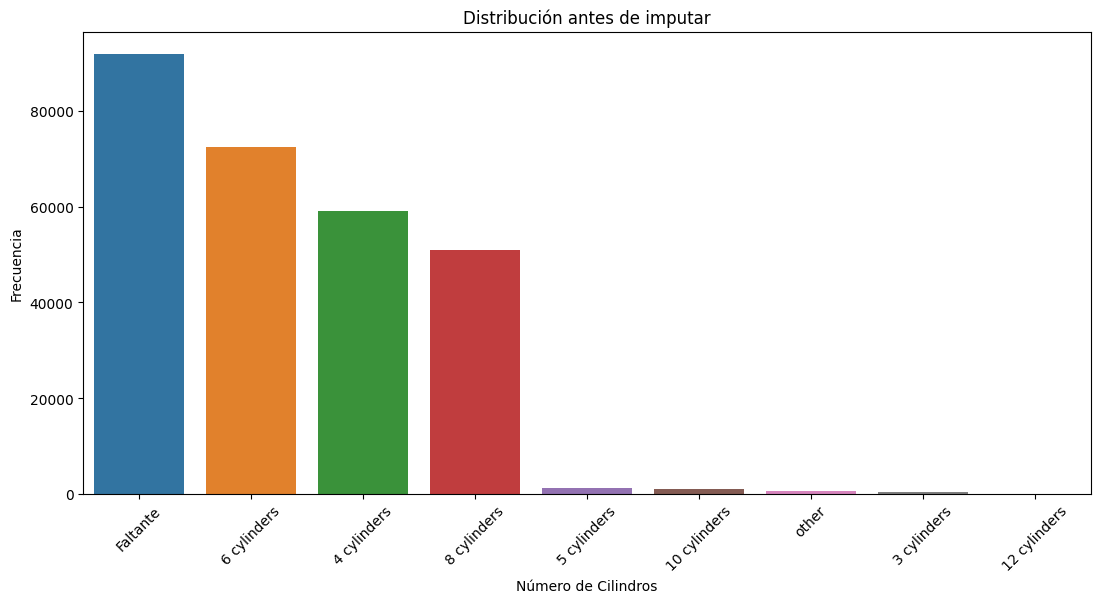

In [20]:
plt.figure(figsize=(13, 6))
plt.title("Distribución antes de imputar")

# Contar manualmente incluyendo NaN
counts = df_cleaned['cylinders'].fillna('Faltante').value_counts()
sns.barplot(x=counts.index.astype(str), y=counts.values)

plt.xlabel("Número de Cilindros")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

Esta variable tiene una representación de NAs, con un total del 41.622470% sin embargo hemos decidido conservarla pues la consideramos util para el modelo. Por la cantidad grande de valores faltantes, introducir con con un unico valor como lo moda global produciría un sesgo fuerte.

In [21]:

# Función para calcular Cramér's V
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# Inicializar diccionario para todas las asociaciones
assoc_results = {}

# --- Variables categóricas ---
cat_cols = df_cleaned.select_dtypes(include=['object', 'category']).columns.tolist()
if 'cylinders' in cat_cols:
    cat_cols.remove('cylinders')

for col in cat_cols:
    assoc_results[col] = cramers_v(df_cleaned['cylinders'], df_cleaned[col])

# --- Variables numéricas ---
num_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'cylinders' in num_cols:
    num_cols.remove('cylinders')

for col in num_cols:
    assoc_results[col] = abs(df_cleaned[col].corr(pd.to_numeric(df_cleaned['cylinders'], errors='coerce')))

# Convertir a DataFrame y ordenar
assoc_df = pd.DataFrame.from_dict(assoc_results, orient='index', columns=['Correlation'])
assoc_df = assoc_df.sort_values(by='Correlation', ascending=False)

print("Asociación de variables con 'cylinders':")
print(assoc_df)

# Top 10 predictores sugeridos
top_predictors = assoc_df.head(10).index.tolist()
print("\nTop 10 predictores sugeridos para imputar 'cylinders':")
print(top_predictors)


Asociación de variables con 'cylinders':
              Correlation
model            0.762634
drive            0.392522
manufacturer     0.343728
type             0.249743
fuel             0.210181
transmission     0.182768
region           0.131778
condition        0.089781
state            0.075290
title_status     0.036240
price                 NaN
year                  NaN
odometer              NaN

Top 10 predictores sugeridos para imputar 'cylinders':
['model', 'drive', 'manufacturer', 'type', 'fuel', 'transmission', 'region', 'condition', 'state', 'title_status']


Debido a la alta correlación con la variable Model contamos con un caso de MAR. Por lo que hemos decidido realizar una imputación con moda condicional, es decir por cada modelo de auto encontraremos su moda y según ello, le asignaremos la moda condicionada al valor faltante. 

In [22]:
# Calcula las modas por grupo
modas_por_grupo = df_cleaned.groupby('model')['cylinders'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
)

# Mapea las modas al DataFrame
df_cleaned['cylinders'] = df_cleaned['cylinders'].fillna(
    df_cleaned['model'].map(modas_por_grupo)
)

# Imputa valores restantes con moda global
moda_global = df_cleaned['cylinders'].mode()[0]
df_cleaned['cylinders'] = df_cleaned['cylinders'].fillna(moda_global)

print("\nValores nulos después:", df_cleaned['cylinders'].isnull().sum())


Valores nulos después: 0


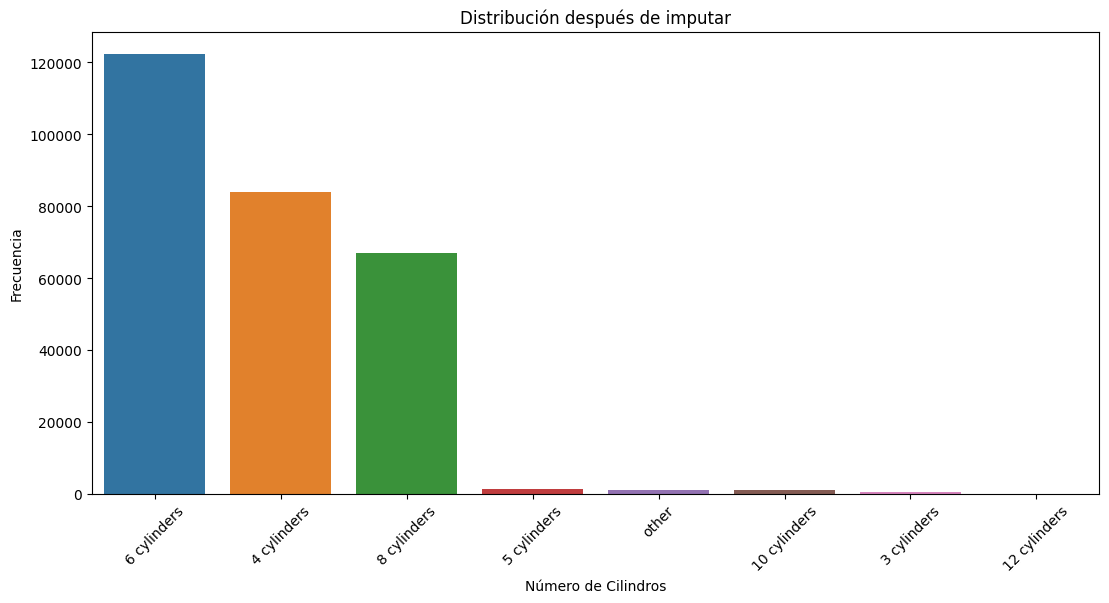

In [23]:
plt.figure(figsize=(13, 6))
plt.title("Distribución después de imputar")

# Contar manualmente incluyendo NaN
counts = df_cleaned['cylinders'].fillna('Faltante').value_counts()
sns.barplot(x=counts.index.astype(str), y=counts.values)

plt.xlabel("Número de Cilindros")
plt.ylabel("Frecuencia")
plt.xticks(rotation=45)
plt.show()

Observamos que la distribución de los datos se mantiene correctamente, por lo que la imputación es válida.

#### 2. `condition`

Un valor faltante podría correlacionarse con una condición promedio o mala, pues un vendedor orgulloso de su auto "excelente" casi siempre lo especificará. Al crear una categoría `unknown`, dejamos que el modelo de Machine Learning aprenda por sí mismo qué significa un `condition` faltante.

In [24]:
df_cleaned['condition'] = df_cleaned['condition'].fillna('unknown')

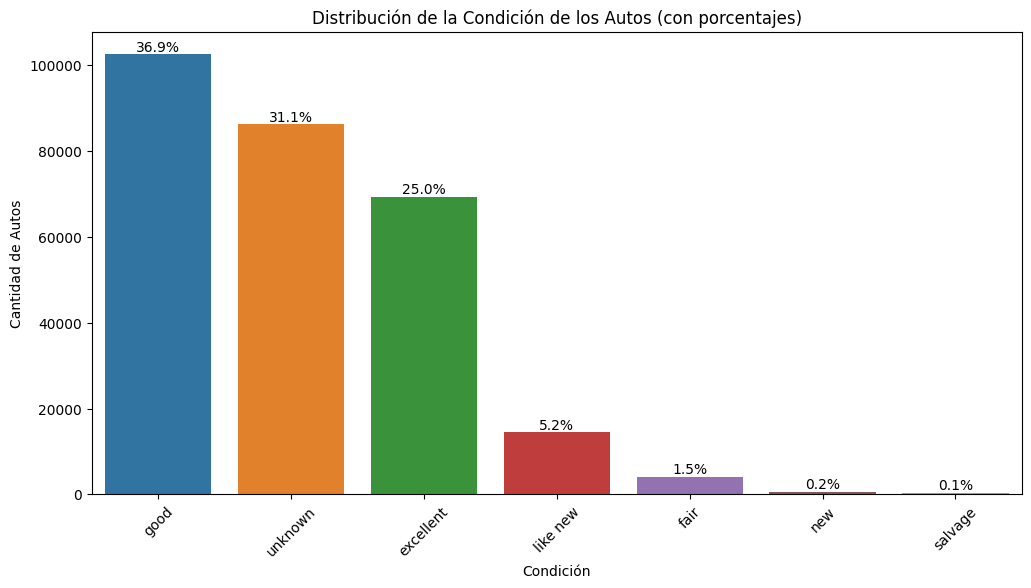

In [25]:
plt.figure(figsize=(12, 6))
ax = sns.countplot(data=df_cleaned, x='condition', order=df_cleaned['condition'].value_counts().index)

# Agregar porcentajes en las barras
total = len(df_cleaned)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    ax.annotate(percentage, 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title('Distribución de la Condición de los Autos (con porcentajes)')
plt.xlabel('Condición')
plt.ylabel('Cantidad de Autos')
plt.xticks(rotation=45)
plt.show()

In [26]:
df_cleaned.shape

(277771, 14)

#### 3. `drive` y `type`

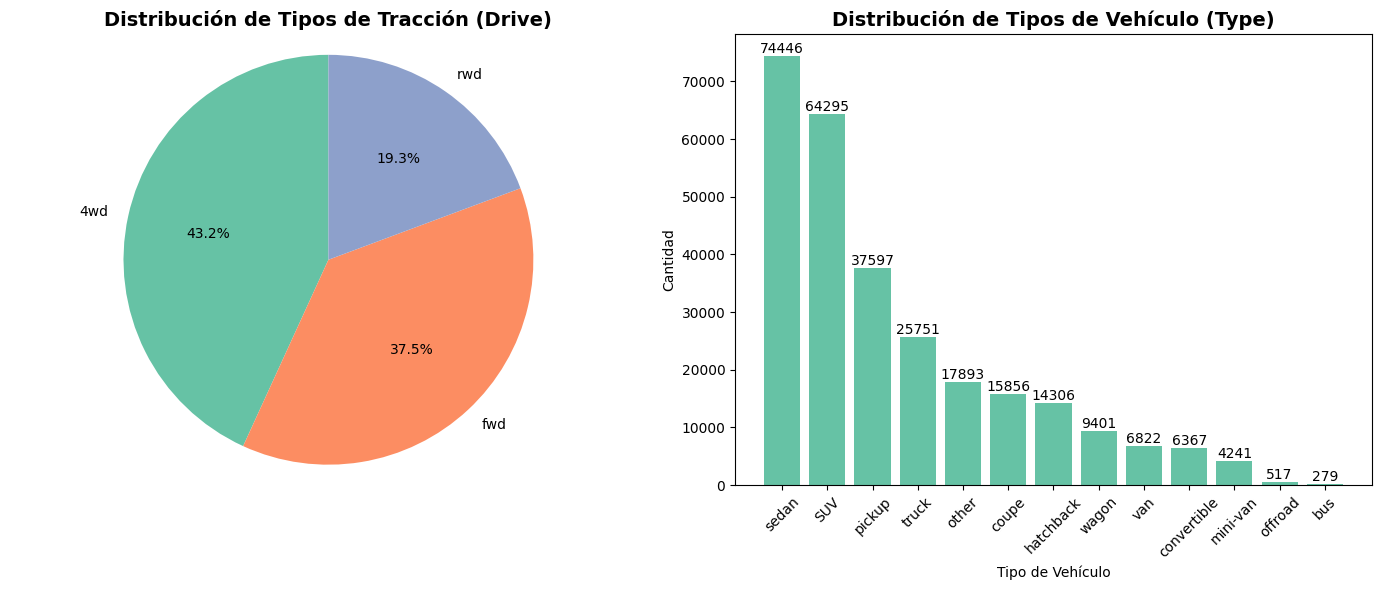

Distribución de Drive:
drive
4wd    95404
fwd    82889
rwd    42713
Name: count, dtype: int64

Distribución de Type:
type
sedan          74446
SUV            64295
pickup         37597
truck          25751
other          17893
coupe          15856
hatchback      14306
wagon           9401
van             6822
convertible     6367
mini-van        4241
offroad          517
bus              279
Name: count, dtype: int64


In [27]:
# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("Set2")

# Crear figura con dos subplots en la misma fila
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Distribución de 'drive'
drive_counts = df_cleaned['drive'].value_counts()
ax1.pie(drive_counts.values, labels=drive_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Distribución de Tipos de Tracción (Drive)', fontsize=14, fontweight='bold')
ax1.axis('equal')  # Para que el pie chart sea circular

# Gráfico 2: Distribución de 'type'
type_counts = df_cleaned['type'].value_counts()
bars = ax2.bar(type_counts.index, type_counts.values)
ax2.set_title('Distribución de Tipos de Vehículo (Type)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tipo de Vehículo')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=45)

# Añadir valores en las barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print("Distribución de Drive:")
print(drive_counts)
print("\nDistribución de Type:")
print(type_counts)

El tipo de vehículo y la tracción a menudo pueden deducirse del modelo. Por ejemplo, un "Ford F-150" es casi siempre un "truck" (camioneta) y a menudo es "4x4" o "rwd".

In [28]:
# Crear un mapa de modelos a tipos/tracciones más comunes
# Esto se puede hacer analizando las filas donde los datos NO son nulos
model_to_type = df_cleaned.dropna(subset=['type']).groupby('model')['type'].agg(lambda x: x.mode()[0])
model_to_drive = df_cleaned.dropna(subset=['drive']).groupby('model')['drive'].agg(lambda x: x.mode()[0])

# Aplicar el mapa para rellenar NAs
df_cleaned['type'] = df_cleaned['type'].fillna(df_cleaned['model'].map(model_to_type))
df_cleaned['drive'] = df_cleaned['drive'].fillna(df_cleaned['model'].map(model_to_drive))

In [29]:
print("\nValores nulos de drive después:", df_cleaned['drive'].isnull().sum())
print("\nValores nulos de type después:", df_cleaned['type'].isnull().sum())


Valores nulos de drive después: 13035

Valores nulos de type después: 0


El resto se le hará drop.

In [30]:
df_cleaned = df_cleaned.dropna(subset=['drive'])

Revisando la nueva distribución.

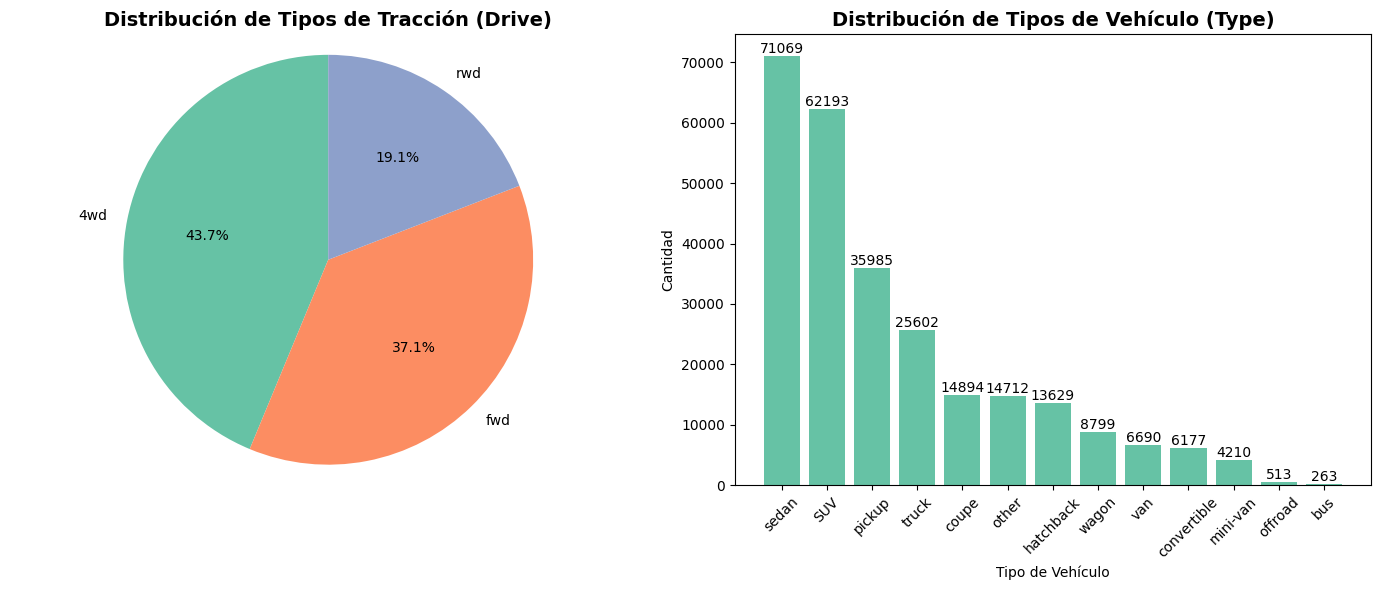

Distribución de Drive:
drive
4wd    115806
fwd     98312
rwd     50618
Name: count, dtype: int64

Distribución de Type:
type
sedan          71069
SUV            62193
pickup         35985
truck          25602
coupe          14894
other          14712
hatchback      13629
wagon           8799
van             6690
convertible     6177
mini-van        4210
offroad          513
bus              263
Name: count, dtype: int64


In [31]:
# Configurar el estilo de los gráficos
plt.style.use('default')
sns.set_palette("Set2")

# Crear figura con dos subplots en la misma fila
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Gráfico 1: Distribución de 'drive'
drive_counts = df_cleaned['drive'].value_counts()
ax1.pie(drive_counts.values, labels=drive_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Distribución de Tipos de Tracción (Drive)', fontsize=14, fontweight='bold')
ax1.axis('equal')  # Para que el pie chart sea circular

# Gráfico 2: Distribución de 'type'
type_counts = df_cleaned['type'].value_counts()
bars = ax2.bar(type_counts.index, type_counts.values)
ax2.set_title('Distribución de Tipos de Vehículo (Type)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Tipo de Vehículo')
ax2.set_ylabel('Cantidad')
ax2.tick_params(axis='x', rotation=45)

# Añadir valores en las barras
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{int(height)}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Mostrar estadísticas adicionales
print("Distribución de Drive:")
print(drive_counts)
print("\nDistribución de Type:")
print(type_counts)

In [32]:
df_cleaned.shape

(264736, 14)

## **Análisis Post-Imputación**

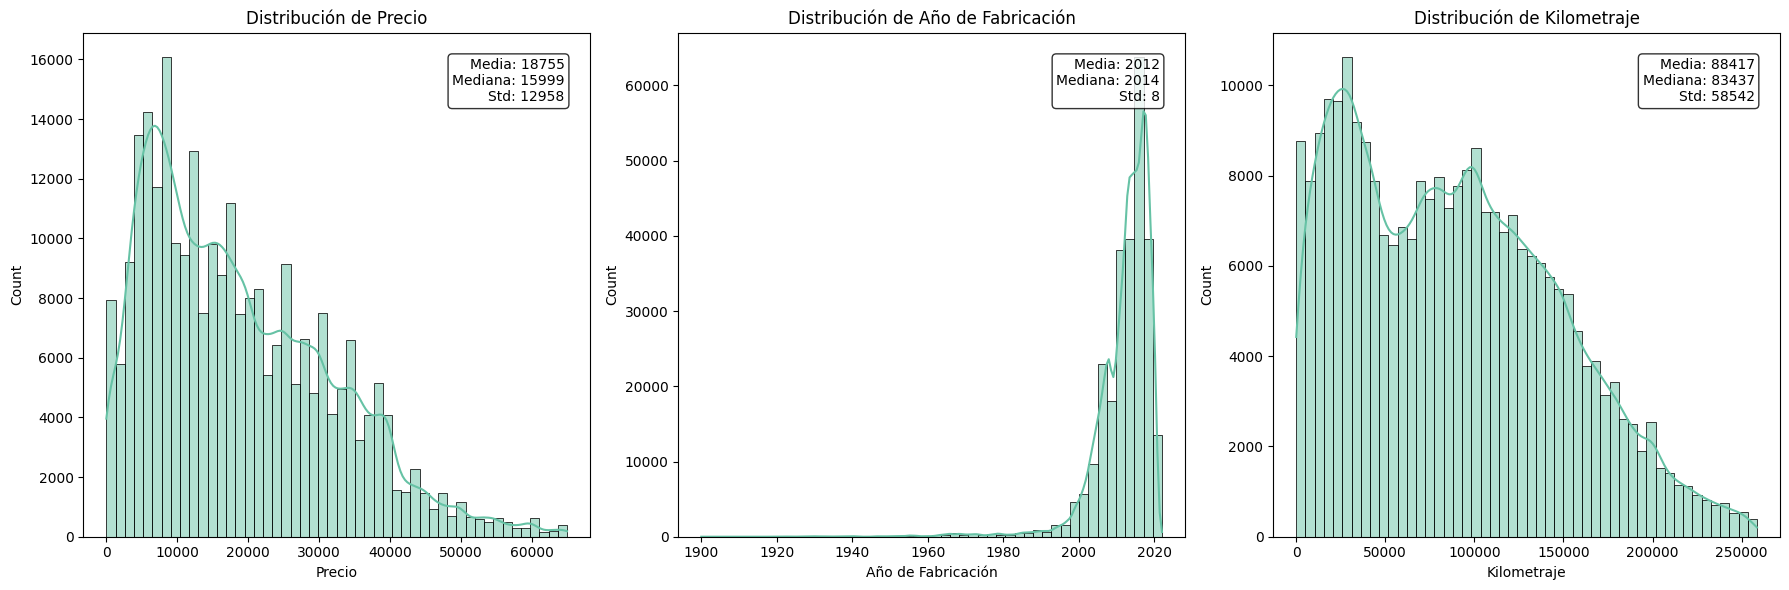

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

variables = ['price', 'year', 'odometer']
titles = ['Precio', 'Año de Fabricación', 'Kilometraje']

for i, var in enumerate(variables):
    sns.histplot(df_cleaned[var], bins=50, kde=True, ax=axes[i])
    
    # Agregar estadísticas al gráfico
    stats_text = f"Media: {df_cleaned[var].mean():.0f}\nMediana: {df_cleaned[var].median():.0f}\nStd: {df_cleaned[var].std():.0f}"
    axes[i].text(0.95, 0.95, stats_text, transform=axes[i].transAxes, 
                verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[i].set_title(f'Distribución de {titles[i]}')
    axes[i].set_xlabel(titles[i])

plt.tight_layout()
plt.show()

**Distribución de Precios:**
Los precios muestran una fuerte asimetría positiva. La mayoría de los vehículos se concentran en rangos bajos (< 50,000), mientras que algunos vehículos premium crean una cola extensa hacia la derecha. La diferencia entre media (19,441) y mediana (16,496) confirma este sesgo - la mediana representa mejor el precio típico al no verse afectada por los outliers.

**Año de Fabricación:**
Observamos una asimetría negativa, indicando predominio de vehículos modernos. Con una mediana de 2014, el 50% del dataset corresponde a vehículos fabricados después de ese año. Los pocos vehículos antiguos reducen la media (2012), pero representan una fracción mínima del conjunto. La baja desviación estándar (8 años) confirma la concentración.

**Kilometraje:**
Esta variable presenta la distribución más cercana a la normalidad, con ligero sesgo positivo. La concentración principal está entre 50,000-150,000 km, representando el uso típico de vehículos usados. La proximidad entre media (87,727) y mediana (82,459) indica menor influencia de outliers comparado con el precio.

### **Odometer**

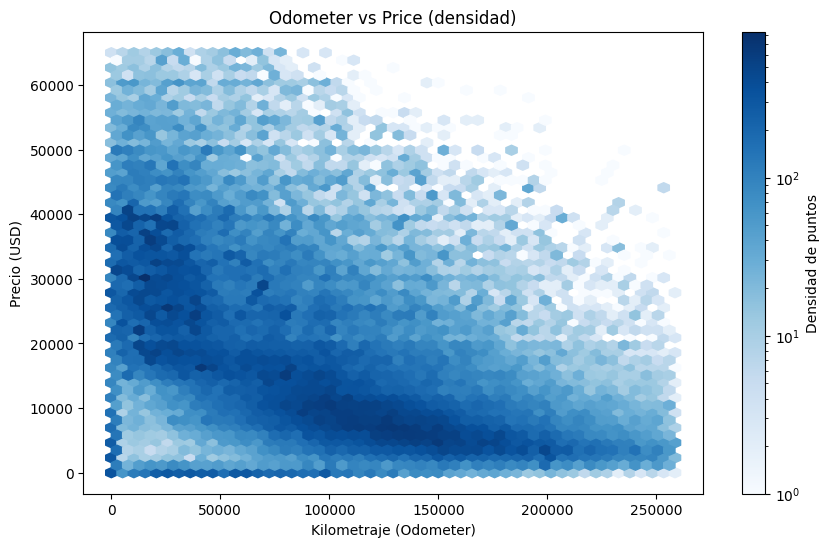

In [34]:
plt.figure(figsize=(10,6))
plt.hexbin(df_cleaned["odometer"], df_cleaned["price"], gridsize=50, cmap="Blues", bins="log")
plt.colorbar(label="Densidad de puntos")
plt.xlabel("Kilometraje (Odometer)")
plt.ylabel("Precio (USD)")
plt.title("Odometer vs Price (densidad)")
plt.show()

El gráfico demuestra una clara relación inversa entre el kilometraje y el precio de un vehículo: a mayor uso, menor es su valor. La mayor concentración de datos se sitúa en vehículos con 50,000 a 150,000 kilómetros y precios entre 5,000 y 25,000 dólares. En los extremos, los coches con bajo kilometraje tienen una dispersión de precios muy amplia, abarcando desde modelos económicos hasta vehículos de lujo casi nuevos, mientras que aquellos con un alto kilometraje se agrupan consistentemente en los rangos de precios más bajos, confirmando la depreciación por el uso intensivo, de igual manera cabe resaltar la  importante variabilidad de manera general de los datos.

### **Modelos**

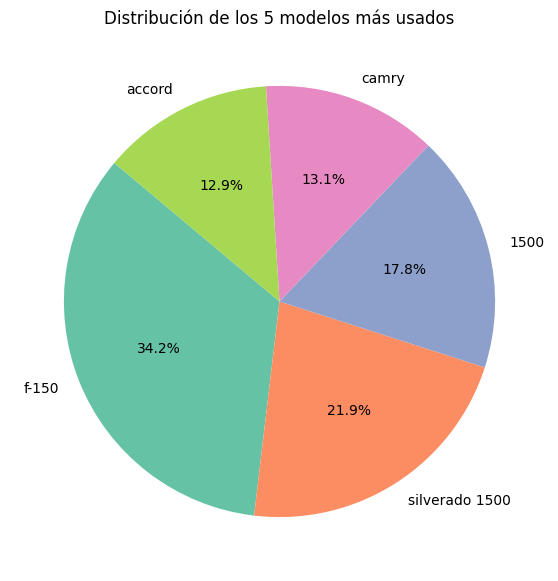

In [35]:
top5_counts = df_cleaned['model'].value_counts().nlargest(5)

plt.figure(figsize=(7,7))
plt.pie(top5_counts, labels=top5_counts.index, autopct='%1.1f%%', startangle=140)
plt.title("Distribución de los 5 modelos más usados")
plt.show()

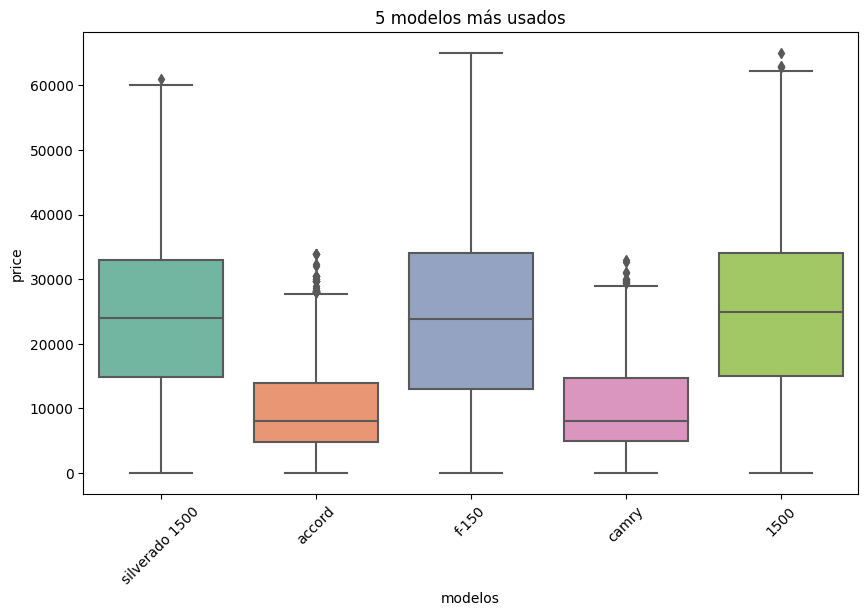

In [36]:
# Obtener los 5 modelos más frecuentes
top5_models = df_cleaned['model'].value_counts().nlargest(5).index

# Filtrar el DataFrame con esos modelos
df_top5 = df_cleaned[df_cleaned['model'].isin(top5_models)]

# Hacer el boxplot (ejemplo con precio, cámbialo por la variable que quieras)
plt.figure(figsize=(10,6))
sns.boxplot(x='model', y='price', data=df_top5)
plt.title("5 modelos más usados")
plt.xlabel("modelos")
plt.xticks(rotation=45)
plt.show()

De los 5 modelos más usados sabemos, que el '1500' y el 'f-150'  son los que la alcanzan consitentemente, los precios más altos sin embargo tienen diferentes ofertas de precio que varían para el 50% de los datos entre 15000 USD y aproxiadamente 32000 USD. Los modelos 'Camry' y 'Accord' son los más baratos del top 5 más usados, y tienen una variabilidad menor respecto a la oferta del precio, a excepción de ocasiones extrañas donde sus precios alcanzas más e 26000 USD aproximadamente. El modelo 'f-150' es el que tiene mayor diferentes ofertas de precios

### **Año**

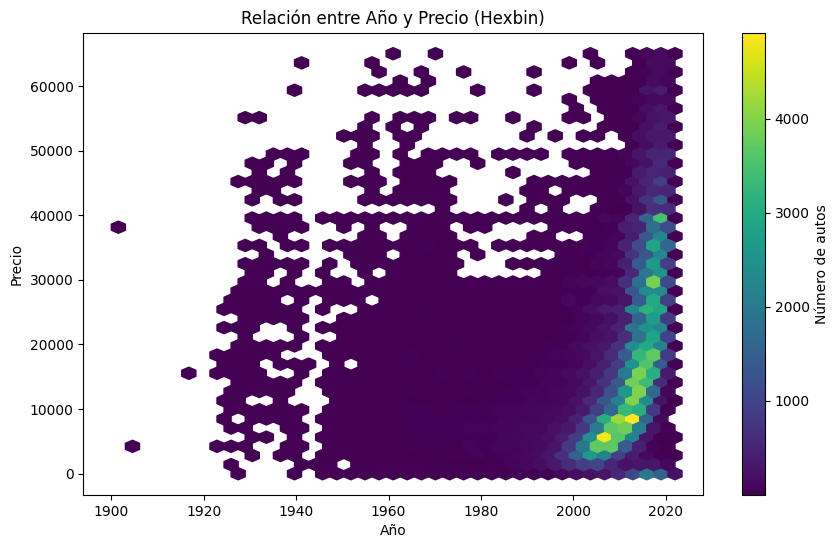

In [37]:
plt.figure(figsize=(10,6))
hb = plt.hexbin(df_cleaned['year'], df_cleaned['price'], 
                gridsize=40, cmap='viridis', mincnt=1)

plt.colorbar(hb, label='Número de autos')
plt.xlabel('Año')
plt.ylabel('Precio')
plt.title('Relación entre Año y Precio (Hexbin)')
plt.show()

Observamos que los vehiculos el año 2000 hacía atrás los precios y el año no están muy relaciondos pues no tienen una gran variabilidad. Sin embargo su concentración sigue estando más cerca de los precios bajos. A partir del año 2000 hacía adelante empieza a existir, una correlación positiva, entre el el año y el precio. Es decir, mientras el vehículo es más nuevo más caro es. Aunque esto tambien puede ser por sesgo, ya que existen más representación de los autos del año 2000 en adelante que los de antes del 2000

### **Transmisión**

Text(0.5, 0, 'Transmission')

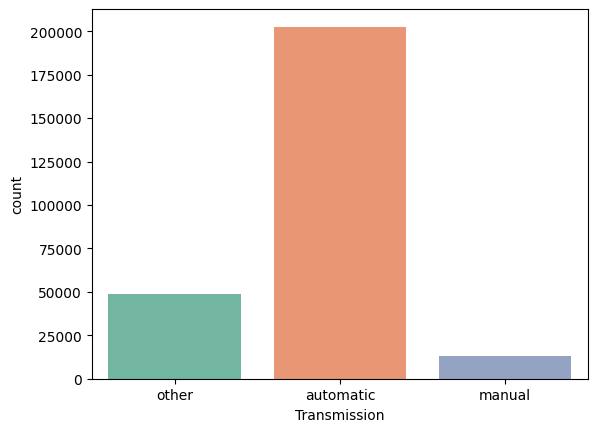

In [38]:
sns.countplot(x= 'transmission', data = df_cleaned)
plt.xlabel("Transmission")

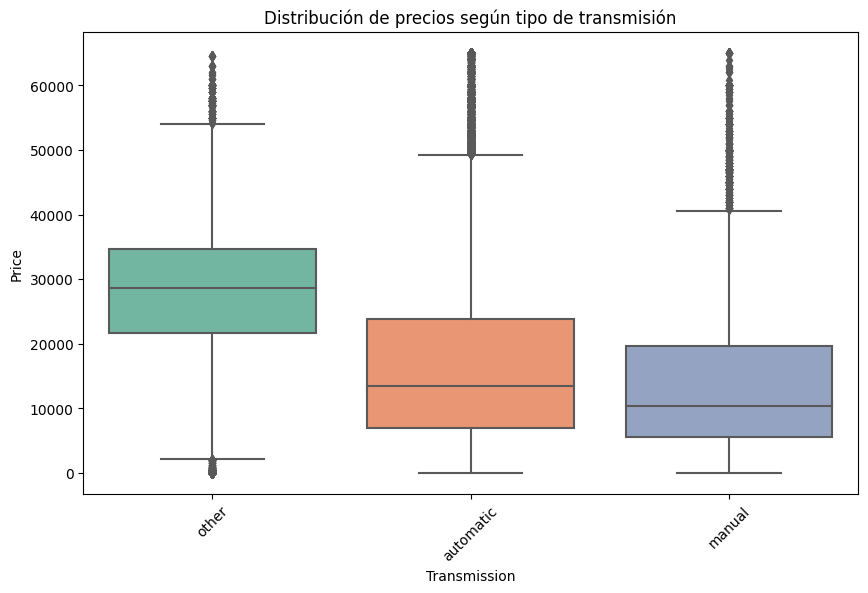

In [39]:
plt.figure(figsize=(10,6))
sns.boxplot(x="transmission", y="price", data=df_cleaned)

plt.xlabel("Transmission")
plt.ylabel("Price")
plt.title("Distribución de precios según tipo de transmisión")
plt.xticks(rotation=45)
plt.show()

Vemos que los vehículos (aunque con poca representacaión)que tienen un transmisor distinto al manual y al automatico, suelen tener precios mayores. Mientras que los manuales son los más baratos, con el 50% de estos precios entre 5000 usd y 20000 USD aproximadamente y rara vez exceden los 40000 USD. Los automaticos suelen ser un poco más caros que los manuales aunque con mayor variabilidad en le rango de precios y en ocasiones extrañs se encuentran evaluados en más de 47000 USD

### **Cilindros**

<Axes: xlabel='cylinders', ylabel='count'>

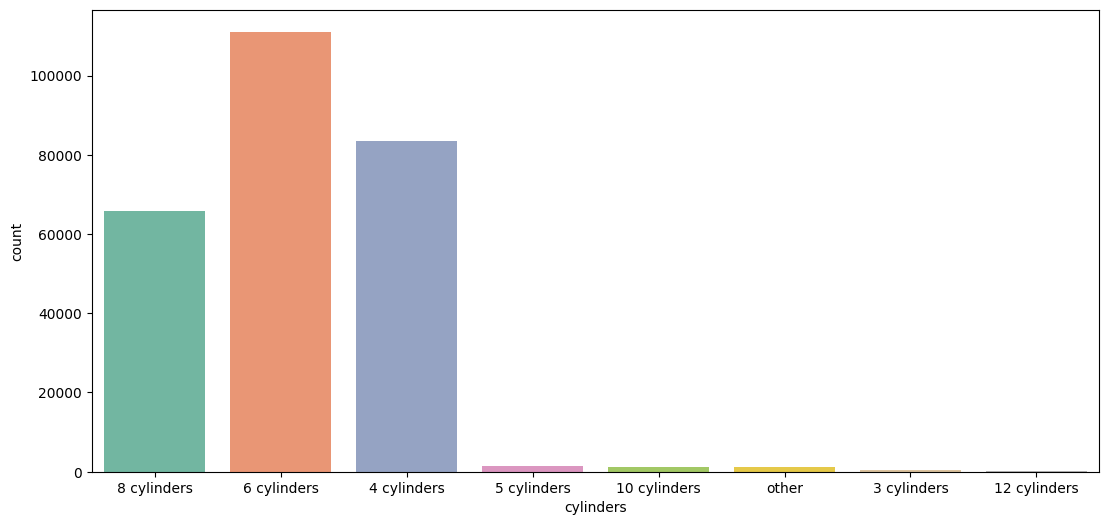

In [40]:
plt.figure(figsize=(13, 6))
sns.countplot(x="cylinders", data = df_cleaned)

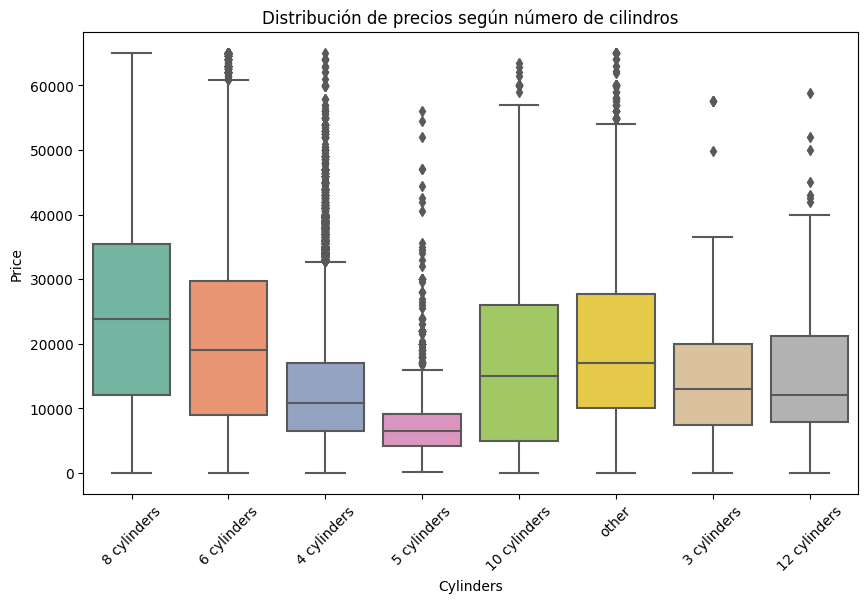

In [41]:
plt.figure(figsize=(10,6))
sns.boxplot(x="cylinders", y="price", data=df_cleaned)

plt.xlabel("Cylinders")
plt.ylabel("Price")
plt.title("Distribución de precios según número de cilindros")
plt.xticks(rotation=45)
plt.show()

Los autos con un total de 5 cilindros, aunque con poca representación (posible sesgo) son los más baratos. Mientras que los que tienen 8, 4 o 6 cilindros suelen ser más comunes. Siendo el más elevado en precio de estos los que tienen hasta 8 cilindros variando el 50% de la oferta de estos precios entre 10000 USD y 34000 USD aproximadamente. Mientras que el 4 es el más economico, de los 3 más comunes alcanzando un precio maximo de 330000 USD aproximadamente y en raras ocsiones excediente este precio

### **Fabricantes**

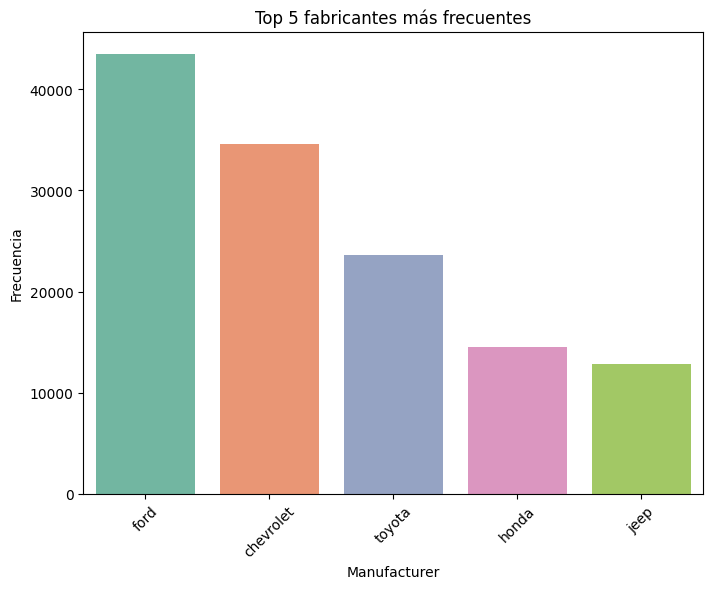

In [42]:
top5_manufacturer = df_cleaned["manufacturer"].value_counts().head(5)

plt.figure(figsize=(8,6))
sns.barplot(x=top5_manufacturer.index, y=top5_manufacturer.values)

plt.xlabel("Manufacturer")
plt.ylabel("Frecuencia")
plt.title("Top 5 fabricantes más frecuentes")
plt.xticks(rotation=45)
plt.show()

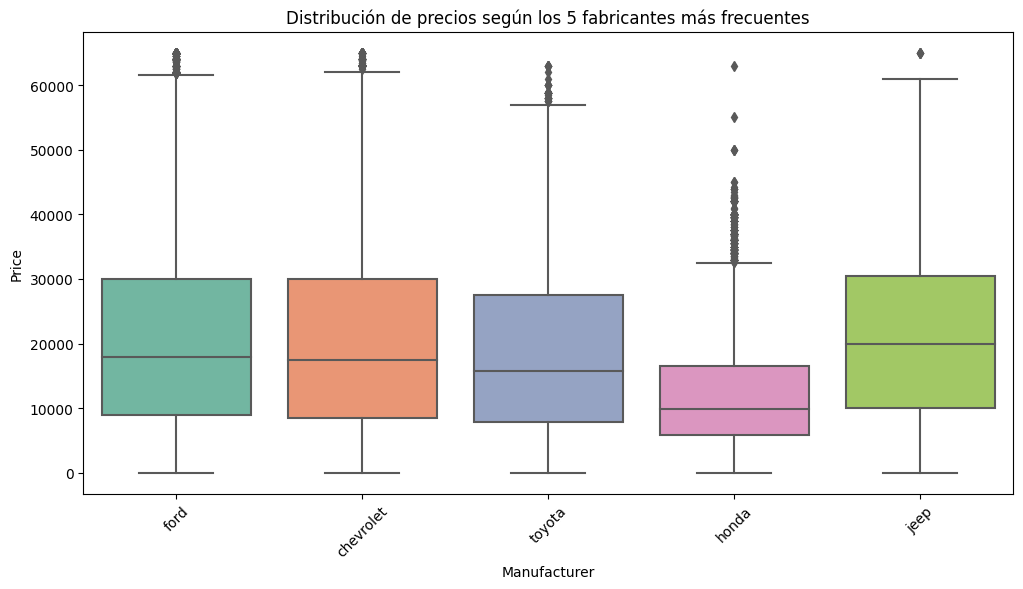

In [43]:
# Filtrar solo fabricantes del top 5
df_top5 = df_cleaned[df_cleaned["manufacturer"].isin(top5_manufacturer.index)]

plt.figure(figsize=(12,6))
sns.boxplot(x="manufacturer", y="price", data=df_top5, order=top5_manufacturer.index)

plt.xlabel("Manufacturer")
plt.ylabel("Price")
plt.title("Distribución de precios según los 5 fabricantes más frecuentes")
plt.xticks(rotation=45)
plt.show()

Ford es los fabricantes más comunes en los vehículos de nuestros datos, además los que tienen mayor variabilidad de precio. Por lo que puede explicar que sean los fabricantes con más ventas, teniendo un publico mayor de esta manera. Su rango de precios está concentrado entre 8000 USD y 30000 USD aproximadamente. Los más vehiculos más economicos, aunque con menor representación es honda y a su vez son la fabricora con rangos de precios más bajos, manteniendo un publico más controlado que ford y rara vez excediendo los precios por arriba de 330000 USD.

### **Ingeniería de características (HighDemand)**

In [44]:
# Tarea 1.5: Generar la variable binaria HighDemand
median_price = df_cleaned['price'].median()
df_cleaned['HighDemand'] = (df_cleaned['price'] > median_price).astype(int)

print(f"Variable 'HighDemand' creada. Mediana del precio: ${median_price:,.2f}")
print("\nDistribución de la nueva variable:")
print(df_cleaned['HighDemand'].value_counts(normalize=True))

Variable 'HighDemand' creada. Mediana del precio: $15,999.00

Distribución de la nueva variable:
HighDemand
0    0.501394
1    0.498606
Name: proportion, dtype: float64


## **Modelos**

In [ ]:
# Importaciones de Scikit-learn para modelado
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Modelos a utilizar
from sklearn.linear_model import Ridge, Lasso, LogisticRegression

# Métricas de evaluación
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

print("Librerías de scikit-learn importadas.")

Librerías de scikit-learn importadas.


## **Moldelos de Regresión**

In [65]:
df_cleaned.columns

Index(['region', 'price', 'year', 'manufacturer', 'model', 'condition',
       'cylinders', 'fuel', 'odometer', 'title_status', 'transmission',
       'drive', 'type', 'state', 'HighDemand'],
      dtype='object')

In [66]:
df_cleaned.shape

(264736, 15)

### **Ridge**

Usaremos el solver `lsqr` ya que One-hot encoder nos deja una matriz sparse por variables como `model`.

In [68]:
# 1. DEFINIR FEATURES Y TARGET
categorical_features = ['manufacturer', 'model', 'transmission', 
                      'fuel', 'drive', 'type', 'condition', 'title_status', 'cylinders']
numerical_features = ['odometer', 'year']
X = df_cleaned[categorical_features + numerical_features]
y = df_cleaned['price']

# 2. DIVIDIR LOS DATOS EN ENTRENAMIENTO Y PRUEBA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

# 3. CONFIGURAR EL PIPELINE Y PREPROCESADOR
preprocessor_ridge = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

pipeline_ridge = Pipeline(steps=[
    ('preprocessing', preprocessor_ridge),
    ('model', Ridge(solver='lsqr'))
])

# 4. CONFIGURAR Y EJECUTAR GRIDSEARCHCV (sobre los datos de entrenamiento)
param_grid_ridge = {
    'preprocessing__num': [StandardScaler(), 'passthrough'],
    'model__alpha': [0.1, 1, 10, 100]
}

grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv=5,  
    scoring='r2',
    n_jobs=-1
)

# Entrenamos el grid_search SOLO con los datos de entrenamiento
grid_search_ridge.fit(X_train, y_train)

print("Mejor valor de alpha encontrado:", grid_search_ridge.best_params_)
print("Mejor score R² (en validación cruzada):", grid_search_ridge.best_score_)
print("-" * 40)

Mejor valor de alpha encontrado: {'model__alpha': 0.1, 'preprocessing__num': StandardScaler()}
Mejor score R² (en validación cruzada): 0.7603877385449364
----------------------------------------


### **Evaluación Ridge**

Métricas de evaluación sobre el conjunto de prueba:
Mean Absolute Error (MAE): 3788.85
Root Mean Squared Error (RMSE): 6379.60
R-squared (R²): 0.7588
----------------------------------------


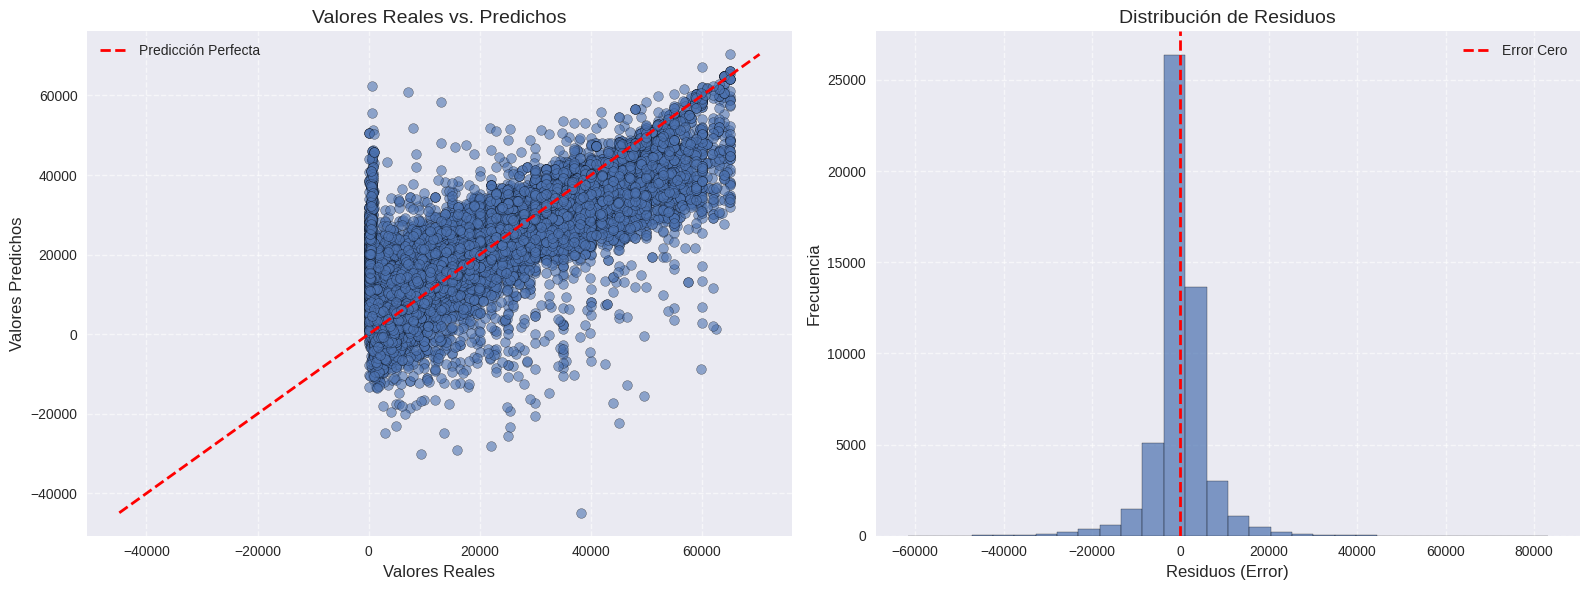

In [70]:
# 5. OBTENER EL MEJOR MODELO Y HACER PREDICCIONES (sobre los datos de prueba)
best_model = grid_search_ridge.best_estimator_
y_pred = best_model.predict(X_test)


# 6. CALCULAR LAS MÉTRICAS DE EVALUACIÓN
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred, squared=False)
r2 = r2_score(y_test, y_pred)

print("Métricas de evaluación sobre el conjunto de prueba:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R²): {r2:.4f}")
print("-" * 40)


# 7. ANÁLISIS VISUAL DEL RENDIMIENTO DEL MODELO
# Crearemos una figura con dos subgráficos para un análisis completo.

plt.style.use('seaborn-v0_8')
# Creamos una figura y un conjunto de subplots (1 fila, 2 columnas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---- Gráfico 1: Valores Reales vs. Predichos ----
axes[0].scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
# Línea de predicción perfecta (y=x)
perfect_line = np.linspace(min(y_test.min(), y_pred.min()), 
                           max(y_test.max(), y_pred.max()), 
                           100)
axes[0].plot(perfect_line, perfect_line, color='red', linestyle='--', linewidth=2, label='Predicción Perfecta')
axes[0].set_title('Valores Reales vs. Predichos', fontsize=14)
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Valores Predichos', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# ---- Gráfico 2: Distribución de los Errores (Residuos) ----
# Calculamos los residuos (error = real - predicho)
residuos = y_test - y_pred

# Creamos el histograma de los residuos
axes[1].hist(residuos, bins=30, alpha=0.7, edgecolor='black')
# Línea vertical en cero para ver si los errores están centrados
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error Cero')
axes[1].set_title('Distribución de Residuos', fontsize=14)
axes[1].set_xlabel('Residuos (Error)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Ajusta el layout para que no se solapen los títulos y muestra la figura
plt.tight_layout()
plt.show()

**Performance General:**
El modelo Ridge alcanza un R² = 0.7588, explicando aproximadamente el 76% de la varianza en precios. Esto indica una relación sólida entre las features y el target, pero las métricas de error revelan problemas importantes en la precisión.

**Métricas de Error:**
El MAE (3,788) nos da el error promedio esperado, mientras que el RMSE (6,379) es significativamente mayor. Esta diferencia indica que el modelo comete errores grandes en ciertos casos - el RMSE penaliza más estos outliers, sugiriendo que algunas predicciones están muy desviadas.

**Análisis Visual:**
El plot revela patrones problemáticos:
- **Heterocedasticidad:** La varianza de los residuos aumenta con el precio real, mostrando menor precisión en vehículos caros
- **Predicciones negativas:** Problema fundamental - el modelo genera precios negativos, lo cual no es realista
- **Subestimación sistemática:** Para vehículos >$40k, el modelo tiende a predecir por debajo del valor real

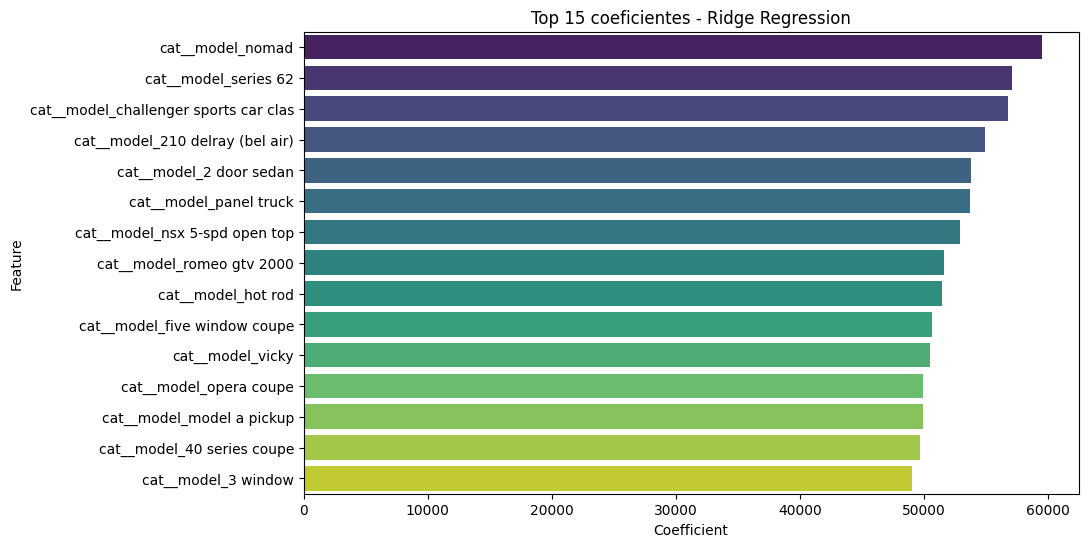

In [52]:
feature_names = (
    grid_search_ridge.best_estimator_
    .named_steps['preprocessing']   # ColumnTransformer
    .get_feature_names_out()
)

coef_ridge = grid_search_ridge.best_estimator_.named_steps['model'].coef_

ridge_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coef_ridge
}).sort_values(by='Coefficient', key=abs, ascending=False)

#Grafico
plt.figure(figsize=(10,6))
sns.barplot(data=ridge_df.head(15), x='Coefficient', y='Feature', palette='viridis')
plt.title("Top 15 coeficientes - Ridge Regression")
plt.show()

In [53]:
import joblib

# Extraemos el mejor estimador
best_ridge_model = grid_search_ridge.best_estimator_

# Guardamos el modelo en el archivo
joblib.dump(best_ridge_model, 'best_ridge_model.joblib')

print(f"\nModelo guardado exitosamente")


Modelo guardado exitosamente


### **Lasso**

In [54]:
# 1. DEFINIR FEATURES Y TARGET
categorical_features = ['manufacturer','model', 'transmission', 'cylinders', 'type', 'condition', 'fuel', 'drive', 'title_status']
numerical_features = ['odometer', 'year']
X = df_cleaned[categorical_features + numerical_features]
y = df_cleaned['price'].astype(float)

# 2. DIVIDIR LOS DATOS EN ENTRENAMIENTO Y PRUEBA
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)


# 3. PREPROCESAMIENTO: Convertir todo a números
# Este es el paso clave que no puede faltar.
# Creamos las herramientas para transformar las columnas.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough',
    n_jobs=-1
)


preprocessor.fit(X_train)

# Ahora, transformamos ambos conjuntos de datos a formato numérico.
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [57]:
# Crear el pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler(with_mean=False)),
    ('lasso', Lasso(random_state=12))
])

# Definir los parámetros para GridSearch
param_grid = {
    'lasso__alpha': [50, 10, 1],
    'lasso__max_iter': [1000],
    'lasso__tol': [1e-1]
}

# Configurar GridSearchCV
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,  # 5-fold cross validation
    scoring='r2',
    n_jobs=-1,  # Usar todos los núcleos de CPU
    verbose=1  # Mostrar progreso
)

# Entrenar con GridSearch
print("Iniciando GridSearch...")
grid_search.fit(X_train_processed, y_train)

print("\nGridSearch completado!")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor score (R²) en validación cruzada: {grid_search.best_score_:.4f}")

Iniciando GridSearch...
Fitting 5 folds for each of 3 candidates, totalling 15 fits

GridSearch completado!
Mejores parámetros: {'lasso__alpha': 10, 'lasso__max_iter': 1000, 'lasso__tol': 0.1}
Mejor score (R²) en validación cruzada: 0.7587


### **Evaluación Lasso**


EVALUACIÓN DEL MEJOR MODELO
Score en entrenamiento: 0.7939
Score en prueba: 0.7580
Número de features utilizados: 9144
Alpha seleccionado: 10

Métricas en conjunto de prueba:
MSE: 40835762.3245
RMSE: 6390.2866
MAE: 3896.7199

RESULTADOS DE TODAS LAS COMBINACIONES
                                                          params  mean_test_score  std_test_score  rank_test_score
{'lasso__alpha': 10, 'lasso__max_iter': 1000, 'lasso__tol': 0.1}         0.758722        0.002473                1
 {'lasso__alpha': 1, 'lasso__max_iter': 1000, 'lasso__tol': 0.1}         0.758168        0.002421                2
{'lasso__alpha': 50, 'lasso__max_iter': 1000, 'lasso__tol': 0.1}         0.726386        0.003310                3


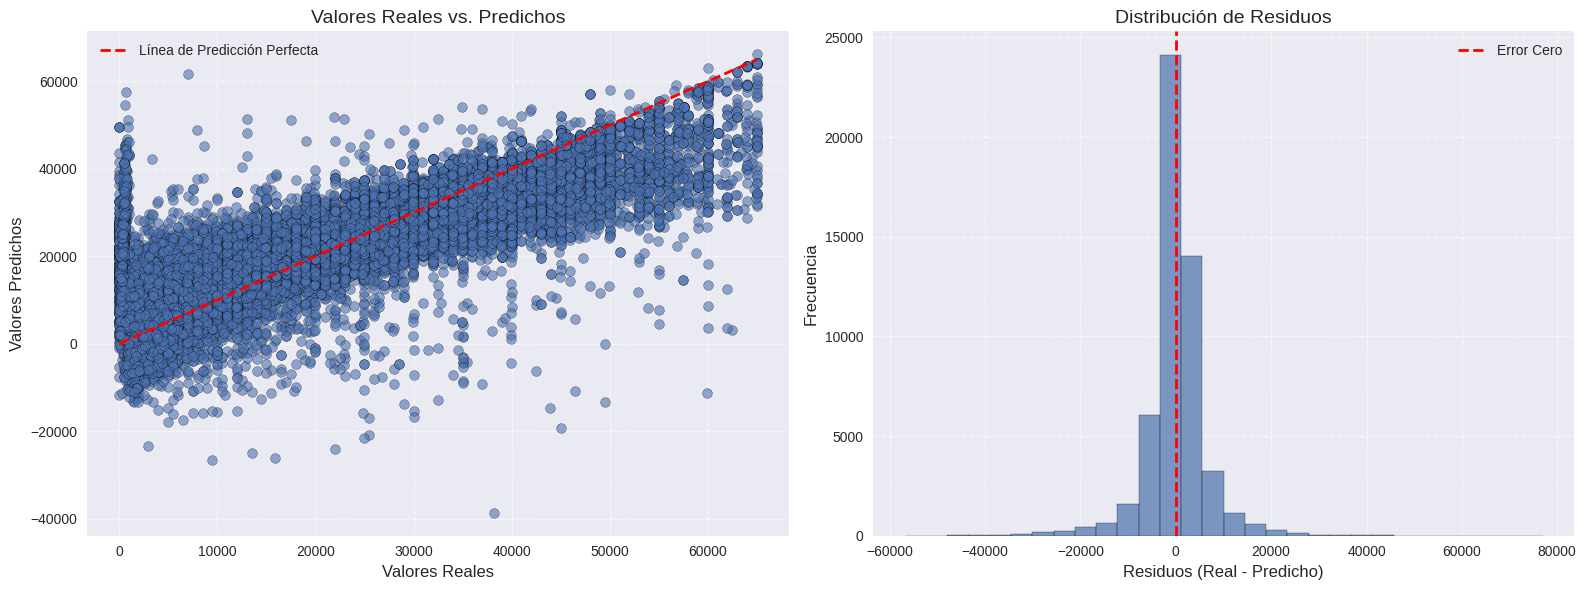


Mejor modelo guardado como 'mejor_modelo_lasso.pkl'


In [60]:
# Obtener el mejor modelo
best_model = grid_search.best_estimator_

# Evaluar en conjunto de prueba
y_test_pred = best_model.predict(X_test_processed)
test_score = best_model.score(X_test_processed, y_test)

# Obtener el modelo Lasso del pipeline
lasso_model = best_model.named_steps['lasso']

# Mostrar resultados detallados
print("\n" + "="*60)
print("EVALUACIÓN DEL MEJOR MODELO")
print("="*60)
print(f"Score en entrenamiento: {best_model.score(X_train_processed, y_train):.4f}")
print(f"Score en prueba: {test_score:.4f}")
print(f"Número de features utilizados: {np.sum(lasso_model.coef_ != 0)}")
print(f"Alpha seleccionado: {lasso_model.alpha}")

# Métricas adicionales
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"\nMétricas en conjunto de prueba:")
print(f"MSE: {mse_test:.4f}")
print(f"RMSE: {rmse_test:.4f}")
print(f"MAE: {mae_test:.4f}")

# Resultados de todos los modelos probados
print("\n" + "="*60)
print("RESULTADOS DE TODAS LAS COMBINACIONES")
print("="*60)
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False)

# Mostrar las mejores 10 combinaciones
top_results = results_df[['params', 'mean_test_score', 'std_test_score', 'rank_test_score']].head(10)
print(top_results.to_string(index=False))

# Configurar el estilo y la figura para las gráficas
plt.style.use('seaborn-v0_8')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# a) Gráfica de valores reales vs predichos
# Un buen modelo tendría los puntos alineados cerca de la línea roja.
axes[0].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Línea de Predicción Perfecta')
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Valores Predichos', fontsize=12)
axes[0].set_title('Valores Reales vs. Predichos', fontsize=14)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.6)

# b) Distribución de residuos (errores)
# Un buen modelo tendría residuos centrados en cero y con una distribución normal.
residuos = y_test - y_test_pred
axes[1].hist(residuos, bins=30, alpha=0.7, edgecolor='black')
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2, label='Error Cero')
axes[1].set_xlabel('Residuos (Real - Predicho)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Residuos', fontsize=14)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.6)

# Ajustar el diseño y mostrar las gráficas
plt.tight_layout()
plt.show()

# Guardar el mejor modelo
joblib.dump(best_model, 'mejor_modelo_lasso.pkl')
print(f"\nMejor modelo guardado como 'mejor_modelo_lasso.pkl'")


**Performance Lasso:**
El modelo Lasso obtiene un R² = 0.7580, prácticamente similar al Ridge (0.7588). Las métricas de error también son similares: MAE 3,896 vs 3,788, y RMSE 6,390 vs 6,379. Esta similitud indica que ambos enfoques de regularización funcionan igual de bien para este dataset.

**Regularización y Overfitting:**
La brecha entre training (0.7939) y test (0.7580) muestra ligero overfitting, pero controlado.

**Selección de Features:**
Aquí está la diferencia clave con Ridge - Lasso debería hacer feature selection automática, pero mantiene 9144 features activas. Esto se debe probablemente a que por razones de tiempo de ejecución tanto el alpha elegido no fue lo suficientemente alto para forzar sparsity como que la tolerancia fue modificada a 1e-1.
En local con diferentes alphas y tolerancia se obtuvo una simplificación de las features, sin embargo, por temas de tiempo y mejorar el score termino así.
**Mismos Problemas:**
Los gráficos son muy parecidos a los de Ridge:
- **Heterocedasticidad persistente:** Mayor varianza en precios altos
- **Predicciones negativas:** El problema conceptual se mantiene
- **Residuos normales:** Distribución centrada en cero con colas largas, confirmando outliers

**Distribución de Residuos:**
La forma aproximadamente normal es buena señal, pero las colas largas confirman la presencia de errores grandes que inflan el RMSE.

## **Moldelo logístico**

In [61]:
# Separar características (X) y el objetivo de clasificación (y)
X = df_cleaned.drop(columns=['price', 'HighDemand'])
y = df_cleaned['HighDemand']

# Identificar columnas numéricas y categóricas
numerical_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

print(f"\nCaracterísticas numéricas ({len(numerical_features)}): {numerical_features}")
print(f"Características categóricas ({len(categorical_features)}): {categorical_features}")

# Dividimos los datos en entrenamiento y prueba. Usamos stratify=y para mantener la proporción de clases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=3, stratify=y
)

print(f"\nDatos divididos: {len(X_train)} para entrenamiento, {len(X_test)} para prueba.")


Características numéricas (2): ['year', 'odometer']
Características categóricas (11): ['region', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'state']

Datos divididos: 211788 para entrenamiento, 52948 para prueba.


In [62]:
# Crear el pipeline de preprocesamiento
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# Crear el pipeline completo que incluye el preprocesador y el modelo
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000, solver='liblinear', random_state=3)) # Añadimos random_state para reproducibilidad
])

print("\nPipeline de Regresión Logística creado.")


# Definir el grid de hiperparámetros para la regularización C
param_grid_logreg = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

# Configurar y ejecutar GridSearchCV para encontrar el mejor hiperparámetro C
grid_search_logreg = GridSearchCV(logreg_pipeline, param_grid_logreg, cv=5, 
                                  scoring='roc_auc', n_jobs=-1)

print("Entrenando modelo de Regresión Logística con GridSearchCV...")
grid_search_logreg.fit(X_train, y_train)

# Guardar el mejor modelo encontrado
best_logreg = grid_search_logreg.best_estimator_

print(f"\nEntrenamiento completado.")
print(f"Mejor puntuación ROC AUC en validación cruzada: {grid_search_logreg.best_score_:.4f}")
print(f"Mejores hiperparámetros: {grid_search_logreg.best_params_}")


Pipeline de Regresión Logística creado.
Entrenando modelo de Regresión Logística con GridSearchCV...

Entrenamiento completado.
Mejor puntuación ROC AUC en validación cruzada: 0.9672
Mejores hiperparámetros: {'model__C': 100}


### **Evaluación Logístico**


--- Evaluación en el Conjunto de Prueba ---

Reporte de Clasificación:
              precision    recall  f1-score   support

Baja Demanda       0.92      0.91      0.91     26548
Alta Demanda       0.91      0.91      0.91     26400

    accuracy                           0.91     52948
   macro avg       0.91      0.91      0.91     52948
weighted avg       0.91      0.91      0.91     52948

Área Bajo la Curva ROC (AUC): 0.9683


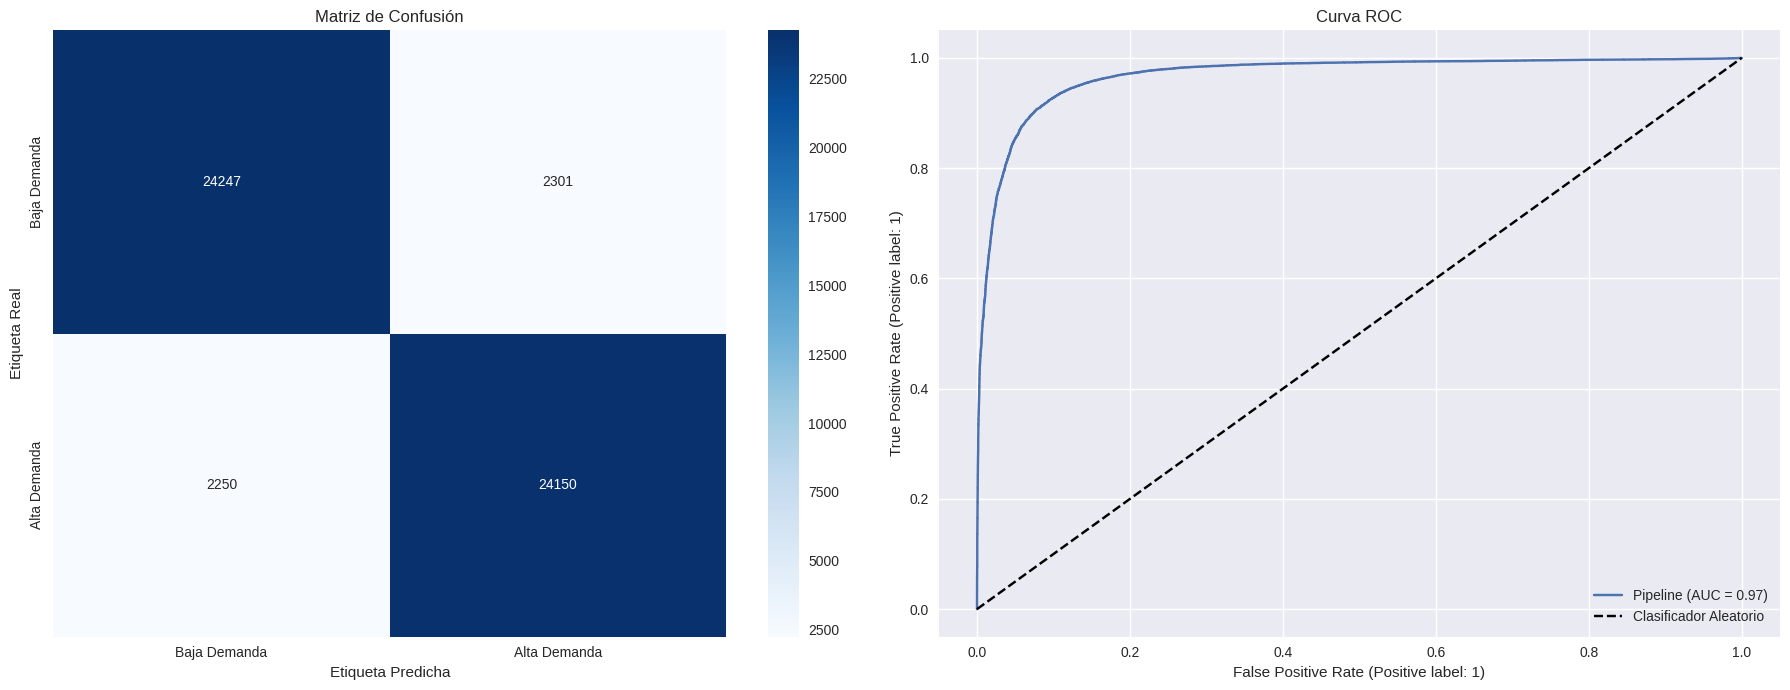

In [63]:
# --- EVALUACIÓN DEL MEJOR MODELO EN EL CONJUNTO DE PRUEBA ---
print("\n--- Evaluación en el Conjunto de Prueba ---")

# Realizar predicciones en el conjunto de prueba
y_pred = best_logreg.predict(X_test)
y_pred_proba = best_logreg.predict_proba(X_test)[:, 1] # Probabilidades para la clase positiva

# Reporte de Clasificación
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['Baja Demanda', 'Alta Demanda']))

# Puntuación ROC AUC
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"Área Bajo la Curva ROC (AUC): {auc_score:.4f}")

# Gráficos: Matriz de Confusión y Curva ROC
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Baja Demanda', 'Alta Demanda'],
            yticklabels=['Baja Demanda', 'Alta Demanda'])
axes[0].set_title('Matriz de Confusión')
axes[0].set_ylabel('Etiqueta Real')
axes[0].set_xlabel('Etiqueta Predicha')

# Curva ROC
RocCurveDisplay.from_estimator(best_logreg, X_test, y_test, ax=axes[1])
axes[1].set_title('Curva ROC')
axes[1].plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio')
axes[1].legend()

plt.tight_layout()
plt.show()

Teniendo en cuenta que la categoría de Demanda fue creada arbitrariamente:

**Performance Logístico:**
El modelo logra un 91% de accuracy con un AUC de 0.97 - métricas que indican performance casi óptima. Con un AUC tan alto, el modelo tiene capacidad discriminatoria excelente: hay 97% de probabilidad de que asigne mayor score a un producto de "Alta Demanda" versus uno de "Baja Demanda".

**Balance Entre Clases:**
Las métricas están equilibradas: precision, recall y f1-score de ~0.91 para ambas clases. Esto es crucial porque significa que el modelo no tiene sesgo hacia ninguna categoría - predice igual de bien alta y baja demanda. El dataset balanceado (26,548 vs 26,400 muestras) garantiza que esta performance es genuina.

**Análisis de Errores:**
La matriz de confusión muestra errores simétricos: ~2,300 falsos positivos y ~2,250 falsos negativos. Esta simetría confirma la ausencia de sesgo sistemático. El modelo se equivoca en ambas direcciones de manera equilibrada.

**Interpretación de la ROC:**
La curva se eleva rápidamente hacia la esquina superior izquierda, indicando que el modelo alcanza alta sensibilidad con muy pocos falsos positivos. Esto es exactamente lo que queremos ver en un clasificador robusto.

## **Conclusiones**

El proyecto atacó dos problemas distintos con resultados contrastantes. La clasificación de demanda obtuvo excelentes resultados, mientras que la predicción de precios estableció un baseline sólido pero reveló la necesidad de enfoques más sofisticados.

### Tarea de Regresión

Ridge y Lasso rindieron prácticamente igual (R² ~0.76), lo cual era esperado dada la configuración empleada. 

**Decisión técnica sobre Lasso:** El modelo no mostró feature selection agresiva porque priorizamos la velocidad sobre sparsity - usamos tolerancia relajada (1e-1) y alpha conservador para optimizar tiempo de ejecución. En experimentos locales con parámetros más estrictos, Lasso sí logra la selección esperada.

**Limitación clave:** El problema no es el tipo de regularización, sino la naturaleza lineal del enfoque. El mercado automotriz tiene dinámicas no lineales que se manifiestan en heterocedasticidad y predicciones negativas.

**Sinergia entre modelos:** Se podría usar la predicción de demanda como feature adicional para el modelo de precios - puede que haya mejoras.